In [7]:
import pandas as pd
import random

# Templates combinatórios estruturados
templates = {
    'investimentos': {
        's': ['', 'Olá', 'Bom dia', 'Por favor', 'Gostaria de saber'],
        'a': ['como aplicar em', 'quero investir em', 'qual a rentabilidade do', 'como funciona o', 'desejo aplicar no'],
        'o': ['tesouro direto', 'cdb de liquidez diaria', 'fundo de investimento', 'lci e lca', 'mercado de acoes']
    },
    'consultas': {
        's': ['', 'Oi', 'Por gentileza', 'Pode me mostrar', 'Preciso ver'],
        'a': ['quero consultar', 'onde vejo', 'qual e o', 'mostre o', 'solicito o'],
        'o': ['meu saldo atual', 'extrato da minha conta', 'comprovante de transferencia', 'saldo disponivel', 'historico de transacoes']
    },
    'pagamentos': {
        's': ['', 'Olá bot', 'Bom dia', 'Urgente', 'Por favor'],
        'a': ['quero pagar', 'como faço para quitar', 'preciso agendar o pagamento do', 'como envio um', 'desejo pagar o'],
        'o': ['boleto de luz', 'codigo de barras', 'pix para chave email', 'cartao de credito', 'imposto veicular']
    },
    'financiamentos': {
        's': ['', 'Olá', 'Gostaria de simular', 'Por gentileza', 'Preciso de ajuda com'],
        'a': ['como contratar', 'quero simular um', 'quais as taxas do', 'como funciona a quitacao do', 'solicito proposta de'],
        'o': ['financiamento imobiliario', 'credito auto', 'financiamento de veiculo', 'credito com garantia', 'parcelamento da casa propria']
    }
}

amostras = []
random.seed(42) # Garantir reprodutibilidade exata das 100 frases

# Gerando exatamente 25 frases por intenção (Total = 100)
for intencao, comp in templates.items():
    for _ in range(25):
        s = random.choice(comp['s'])
        a = random.choice(comp['a'])
        o = random.choice(comp['o'])
        frase = f"{s} {a} {o}".strip().capitalize()
        amostras.append({'texto': frase, 'intencao': intencao})

# Exportação para arquivo CSV
df_banco = pd.DataFrame(amostras)
df_banco.to_csv('dataset_banco_100.csv', index=False, encoding='utf-8')

print(" Arquivo 'dataset_banco_100.csv' gerado com sucesso!")




 Arquivo 'dataset_banco_100.csv' gerado com sucesso!


MÉTRICAS GERAIS DO MODELO (KNN)
Acurácia Geral: 93.33%
F1-Score Geral (Weighted): 93.27%

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                precision    recall  f1-score   support

     consultas       1.00      0.75      0.86         8
financiamentos       0.78      1.00      0.88         7
 investimentos       1.00      1.00      1.00         8
    pagamentos       1.00      1.00      1.00         7

      accuracy                           0.93        30
     macro avg       0.94      0.94      0.93        30
  weighted avg       0.95      0.93      0.93        30



/tmp/ipykernel_5067/3815475189.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='intencao', palette='viridis', ax=axes[1])


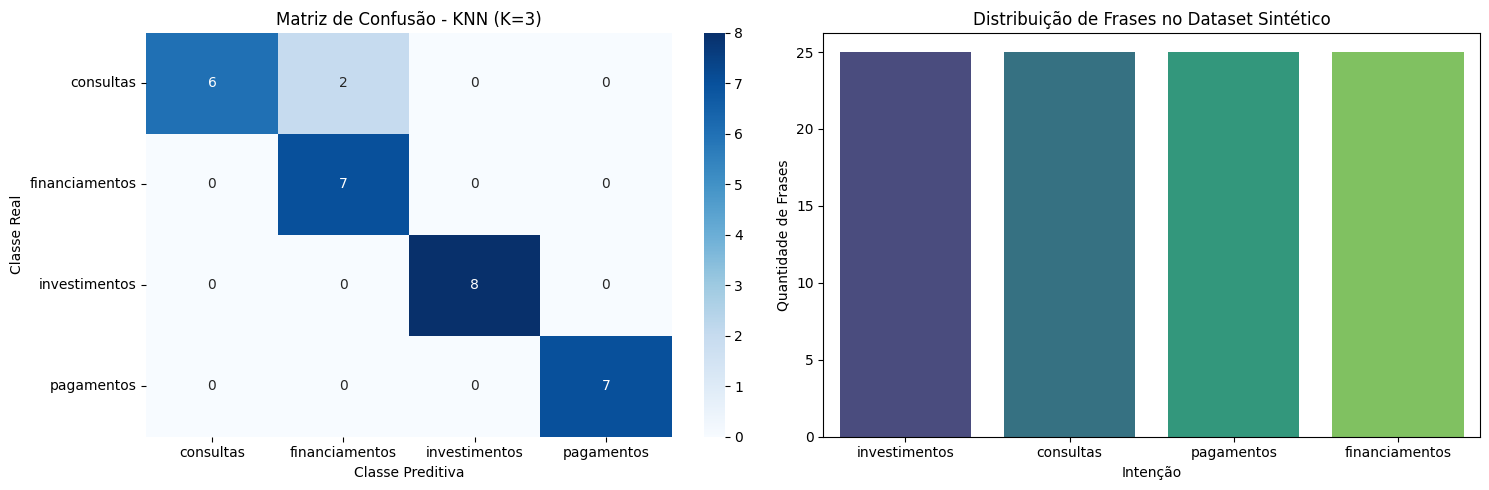

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 1. Carga dos dados salvos no CSV
df = pd.read_csv('dataset_banco_100.csv')

# 2. Divisão Estratificada (Treino / Teste)
X_train, X_test, y_train, y_test = train_test_split(
    df['texto'], df['intencao'], test_size=0.30, random_state=42, stratify=df['intencao']
)

# 3. Construção da Pipeline com TF-IDF + KNN (K=3)
pipeline_nlu = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('classifier', KNeighborsClassifier(n_neighbors=3, metric='cosine'))
])

# 4. Treinamento do Modelo
pipeline_nlu.fit(X_train, y_train)

# 5. Avaliação Estatística
y_pred = pipeline_nlu.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print(f"MÉTRICAS GERAIS DO MODELO (KNN)")
print(f"Acurácia Geral: {acc*100:.2f}%")
print(f"F1-Score Geral (Weighted): {f1*100:.2f}%")
print("="*60)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

# 6. Geração dos Gráficos de Avaliação
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Matriz de Confusão Heatmap
cm = confusion_matrix(y_test, y_pred)
labels = sorted(df['intencao'].unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matriz de Confusão - KNN (K=3)')
axes[0].set_xlabel('Classe Preditiva')
axes[0].set_ylabel('Classe Real')

# Gráfico 2: Distribuição de Amostras por Classe no Dataset
sns.countplot(data=df, x='intencao', palette='viridis', ax=axes[1])
axes[1].set_title('Distribuição de Frases no Dataset Sintético')
axes[1].set_xlabel('Intenção')
axes[1].set_ylabel('Quantidade de Frases')

plt.tight_layout()
plt.show()




In [ ]:
import numpy as np

LIMIAR_CONFIANCA = 0.50

def processar_mensagem(texto):
    # 1. Obtenção das probabilidades do modelo treinado
    probs = pipeline_nlu.predict_proba([texto])[0]
    maior_prob = np.max(probs)
    intencao = pipeline_nlu.predict([texto])[0]

    # 2. Lógica de decisão por Limiar de Confiança
    if maior_prob >= LIMIAR_CONFIANCA:
        print(f"\nBot [Intenção: {intencao.upper()} | Confiança: {maior_prob*100:.1f}%]: ", end="")

        if intencao == "investimentos":
            print("Temos opções de CDB, LCI/LCA e Tesouro Direto. Qual seu perfil de risco?")
        elif intencao == "consultas":
            print("Seu saldo disponível é de R$ 4.820,50. Deseja consultar seu extrato?")
        elif intencao == "pagamentos":
            print("Área de pagamentos iniciada. Por favor, digite ou cole o código de barras.")
        elif intencao == "financiamentos":
            print("Simulador de crédito aberto. Qual o valor do bem que deseja financiar?")

    else:
        # Fallback ativo encaminhando para atendente humano
        print(f"\nBot: [FALLBACK - Confiança baixa: {maior_prob*100:.1f}%]")
        print("Desculpe, não consegui entender sua solicitação. Por favor, aguarde um momento enquanto encaminho você para um atendente humano...")


In [10]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Carregar dataset do CSV
df = pd.read_csv('dataset_banco_100.csv')

# 2. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    df['texto'], df['intencao'], test_size=0.30, random_state=42, stratify=df['intencao']
)

# TODO 1: Monte a Pipeline utilizando TfidfVectorizer e KNeighborsClassifier(n_neighbors=3, metric='cosine')
pipeline_knn = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', KNeighborsClassifier(n_neighbors=3, metric='cosine'))
])

# TODO 2: Treine a pipeline com os dados de treino (X_train, y_train)
pipeline_knn.fit(X_train, y_train)

# TODO 3: Gere as predicoes nos dados de teste e exiba o classification_report e a confusion_matrix
y_pred = pipeline_knn.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

LIMIAR_CONFIANCA = 0.50

print("\n=== INICIANDO BATERIA DE TESTES (10 INPUTS OBRIGATÓRIOS) ===")

for i in range(1, 11):
    print(f"\n[Teste {i}/10]")

    # TODO 4: Solicite a frase do usuario via teclado
    frase = input("Digite a frase do cliente: ").strip()

    # TODO 5: Extraia as probabilidades e a classe prevista usando predict_proba e predict
    probs = pipeline_knn.predict_proba([frase])
    maior_prob = np.max(probs)
    intencao = pipeline_knn.predict([frase])[0]

    # TODO 6: Aplique a regra de decisao
    if maior_prob >= LIMIAR_CONFIANCA:
        print(f"Intenção identificada: {intencao}")
        print(f"Confiança: {maior_prob:.2%}")
    else:
        print("Fallback: encaminhando para atendimento humano.")

    pass



                precision    recall  f1-score   support

     consultas       1.00      0.88      0.93         8
financiamentos       0.88      1.00      0.93         7
 investimentos       1.00      1.00      1.00         8
    pagamentos       1.00      1.00      1.00         7

      accuracy                           0.97        30
     macro avg       0.97      0.97      0.97        30
  weighted avg       0.97      0.97      0.97        30

[[7 1 0 0]
 [0 7 0 0]
 [0 0 8 0]
 [0 0 0 7]]

=== INICIANDO BATERIA DE TESTES (10 INPUTS OBRIGATÓRIOS) ===

[Teste 1/10]
Digite a frase do cliente: Corinthians é maior que o Palmeiras?
Fallback: encaminhando para atendimento humano.

[Teste 2/10]
Digite a frase do cliente: Ferrari é melhor que Mercedes?
Fallback: encaminhando para atendimento humano.

[Teste 3/10]
Digite a frase do cliente: Senna é maior que Hamilton 
Fallback: encaminhando para atendimento humano.

[Teste 4/10]
Digite a frase do cliente: Neymar é melhor que messi?
Fallback: e